In [ ]:
# setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

Training on: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# data augmentation (EfficientNet-B3 uses 300x300)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.normalise([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.normalise([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
# datasets
train_data = datasets.ImageFolder("/content/drive/MyDrive/Data for Colab/aggregated_dataset/train", transform=train_transform)
val_data = datasets.ImageFolder("/content/drive/MyDrive/Data for Colab/aggregated_dataset/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)

Classes: ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Squamous_Cell_Carcinoma', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']


In [ ]:
# visualisation imports
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from PIL import Image
import os

# for reproducibility in visualisations
np.random.seed(42)


/tmp/ipython-input-242646131.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(class_names, rotation=0, ha='right')  # Ensure right alignment
/tmp/ipython-input-242646131.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels(class_names, rotation=0, ha='right')


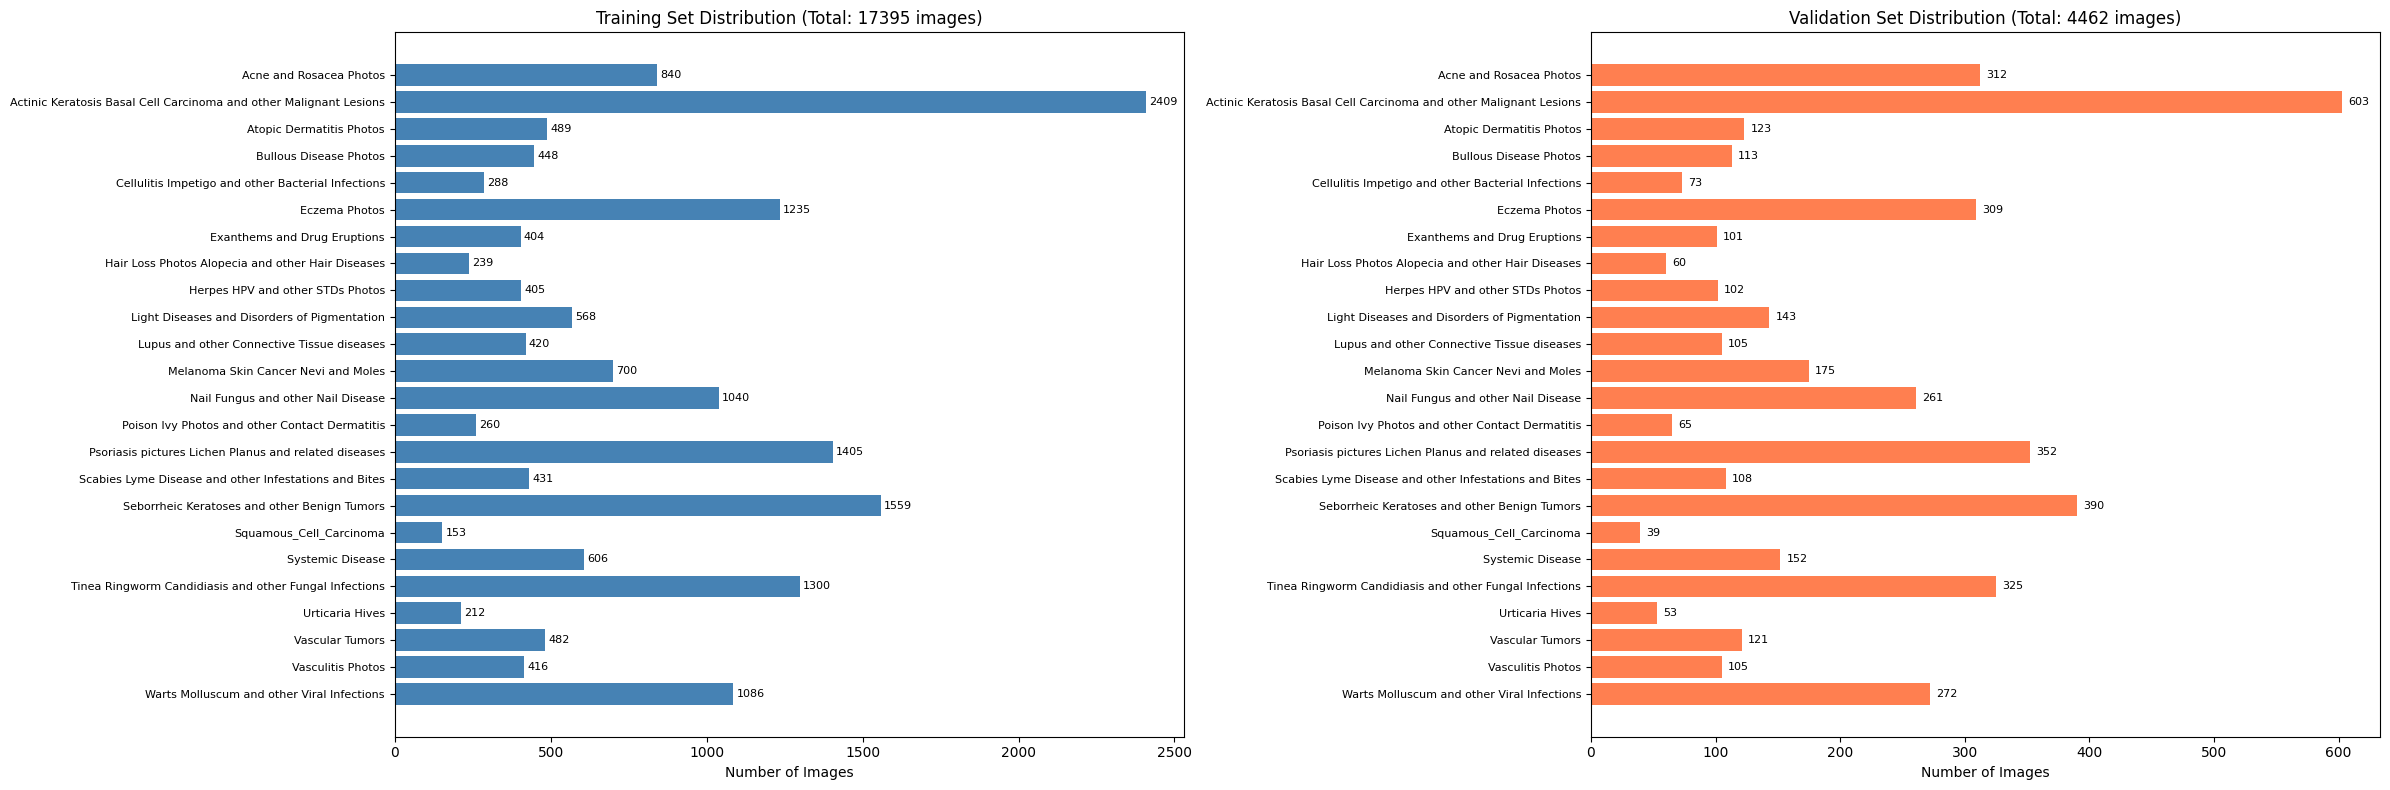

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# training set distribution
train_counts = [class_counts_train[i] for i in range(len(class_names))]
bars1 = axes[0].barh(class_names, train_counts, color='steelblue')
axes[0].set_xlabel('Number of Images')
axes[0].set_title(f'Training Set Distribution (Total: {len(train_data)} images)')
axes[0].invert_yaxis()
axes[0].tick_params(axis='y', labelsize=8)  # Smaller font
axes[0].set_yticklabels(class_names, rotation=0, ha='right')  # Ensure right alignment

# validation set distribution
val_counts = [class_counts_val[i] for i in range(len(class_names))]
bars2 = axes[1].barh(class_names, val_counts, color='coral')
axes[1].set_xlabel('Number of Images')
axes[1].set_title(f'Validation Set Distribution (Total: {len(val_data)} images)')
axes[1].invert_yaxis()
axes[1].tick_params(axis='y', labelsize=8)  # Smaller font
axes[1].set_yticklabels(class_names, rotation=0, ha='right')

for bar, count in zip(bars1, train_counts):
    axes[0].text(count + 10, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=8)
for bar, count in zip(bars2, val_counts):
    axes[1].text(count + 5, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# sample images from each class (1 per class)
# create dataset without transforms to show original images
raw_train_data = datasets.ImageFolder("/content/drive/MyDrive/Data for Colab/aggregated_dataset/train")

n_classes = len(class_names)
cols = 5
rows = (n_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten()

# get one sample image per class
class_to_idx = {v: k for k, v in raw_train_data.class_to_idx.items()}
for class_idx in range(n_classes):
    # find first image of this class
    for img_idx, (_, label) in enumerate(raw_train_data.samples):
        if label == class_idx:
            img_path = raw_train_data.samples[img_idx][0]
            img = Image.open(img_path).convert('RGB')
            axes[class_idx].imshow(img)
            axes[class_idx].set_title(short_names[class_idx], fontsize=8)
            axes[class_idx].axis('off')
            break

# hide unused subplots
for idx in range(n_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# before and after data augmentation comparison
# define augmentation-only transform (no normalisation, for visualisation)
augment_only = transforms.Compose([
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
])

# pick 4 random sample images
sample_indices = np.random.choice(len(raw_train_data), 4, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for row, idx in enumerate(sample_indices):
    img_path, label = raw_train_data.samples[idx]
    original_img = Image.open(img_path).convert('RGB')

    # show original
    axes[row, 0].imshow(original_img)
    axes[row, 0].set_title('Original' if row == 0 else '')
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_ylabel(short_names[label], fontsize=8)

    # show 4 augmented versions
    for col in range(1, 5):
        augmented_img = augment_only(original_img)
        axes[row, col].imshow(augmented_img)
        axes[row, col].set_title(f'Augmented {col}' if row == 0 else '')
        axes[row, col].axis('off')

plt.suptitle('Data Augmentation: Original vs Augmented Samples', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# uses multiple workers to prefetch data in parallel and pins memory for faster GPU transfer
# this was my solution to the first epoch being really slow, it's slightly improved now (not much though tbh)

num_workers = 4  # 4 workers
prefetch_factor = 2  # 2 batches to prefetch per worker

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=prefetch_factor
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=prefetch_factor
)

# warm up the data loaders by iterating once (caches files from Google Drive)
print("Warming up data loaders (this caches files from Google Drive)...")
for _ in tqdm(train_loader, desc="Caching train data"):
    pass
for _ in tqdm(val_loader, desc="Caching val data"):
    pass
print("Data loaders warmed up! Subsequent epochs will be fast.")


Warming up data loaders (this caches files from Google Drive)...


Caching val data: 100%|██████████| 140/140 [08:31<00:00,  3.66s/it]

Data loaders warmed up! Subsequent epochs will be fast.


In [ ]:
# model (EfficientNet-B3)
model = models.efficientnet_b3(pretrained=True)

# freeze backbone except last blocks (features.6 and features.7)
# EfficientNet-B3 structure: features.0-7 -> avgpool -> classifier
# I've unfrozen features.6, features.7, and the classifier head for fine-tuning
for name, param in model.named_parameters():
    if "features.6" not in name and "features.7" not in name and "classifier" not in name:
        param.requires_grad = False

# replace classifier head
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)

# print trainable parameters info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 213MB/s]


Total parameters: 10,733,120
Trainable parameters: 7,950,070 (74.1%)


In [ ]:
# loss + optimisation (shared hyperparameters with ResNet50 for fair comparison)
criterion = nn.CrossEntropyLoss()
optimiser = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)

# scheduler: reduce learning rate if validation loss stays the same or higher for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', patience=2, factor=0.5)

In [ ]:
# train + validation
# history tracking for plotting curves
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

num_epochs = 15  # shared with ResNet50 for fair comparison
for epoch in range(num_epochs):
    model.train()
    running_loss, running_corrects = 0.0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        optimiser.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels)

    epoch_loss = running_loss / len(train_data)
    epoch_acc = (running_corrects.double() / len(train_data)).item()

    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Validation for epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels)

    val_loss /= len(val_data)
    val_acc = (val_corrects.double() / len(val_data)).item()

    # track history using a dictionary
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} "
          f"- Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Validation for epoch 1/15: 100%|██████████| 140/140 [00:19<00:00,  7.15it/s]


Epoch 1/15 - Train Loss: 2.1806, Train Acc: 0.3568 - Val Loss: 1.7850, Val Acc: 0.4657


Validation for epoch 2/15: 100%|██████████| 140/140 [00:19<00:00,  7.10it/s]


Epoch 2/15 - Train Loss: 1.7286, Train Acc: 0.4801 - Val Loss: 1.5902, Val Acc: 0.5253


Validation for epoch 3/15: 100%|██████████| 140/140 [00:19<00:00,  7.16it/s]


...

Epoch 13/15 - Train Loss: 0.2648, Train Acc: 0.9076 - Val Loss: 1.4806, Val Acc: 0.6804


Validation for epoch 14/15: 100%|██████████| 140/140 [00:19<00:00,  7.20it/s]


Epoch 14/15 - Train Loss: 0.2259, Train Acc: 0.9219 - Val Loss: 1.6650, Val Acc: 0.6862


Validation for epoch 15/15: 100%|██████████| 140/140 [00:19<00:00,  7.10it/s]

Epoch 15/15 - Train Loss: 0.2075, Train Acc: 0.9261 - Val Loss: 1.5191, Val Acc: 0.6838


In [ ]:
# save model
torch.save(model.state_dict(), "aggregated_efficientnet_b3.pth")

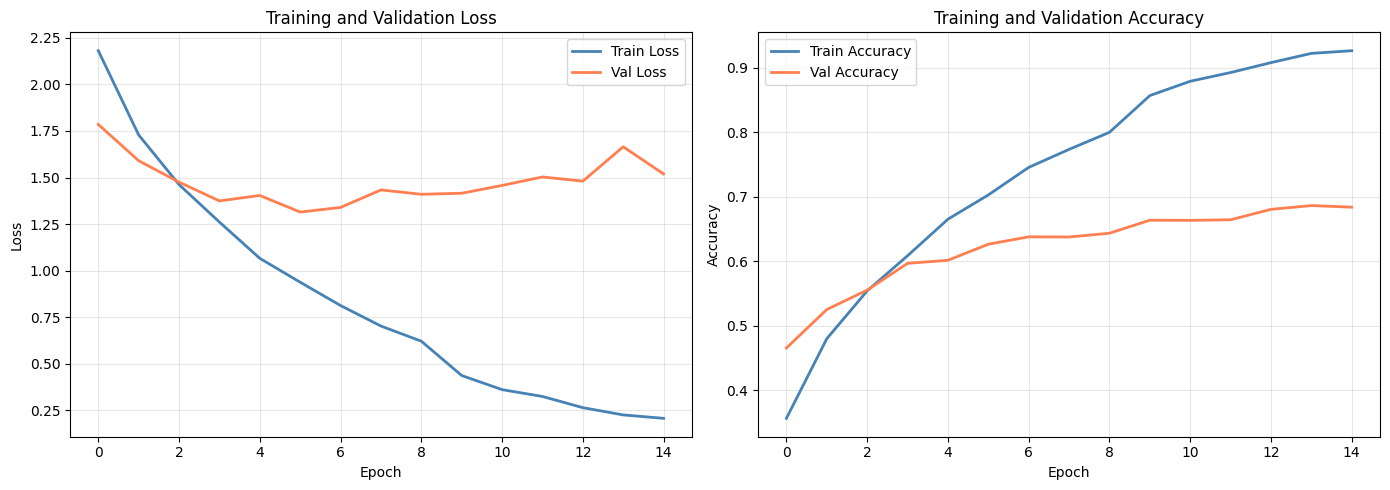

Best validation accuracy: 0.6862 at epoch 14
Final validation accuracy: 0.6838


In [ ]:
# training curves - loss and accuracy over epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss curve
axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', color='coral', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# accuracy curve
axes[1].plot(history['train_acc'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', color='coral', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(history['val_acc']):.4f} at epoch {history['val_acc'].index(max(history['val_acc'])) + 1}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")


In [ ]:
# model evaluation - get predictions on validation set
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


Evaluating: 100%|██████████| 140/140 [00:19<00:00,  7.25it/s]


In [ ]:
# classification report - precision, recall, F1-score for each class
print("Classification Report")
print("=" * 80)
print(classification_report(all_labels, all_preds, target_names=short_names, digits=4))


Classification Report
                         precision    recall  f1-score   support

Acne and Rosacea Pho...     0.8470    0.9583    0.8992       312
Actinic Keratosis Ba...     0.7975    0.8491    0.8225       603
Atopic Dermatitis Ph...     0.6579    0.6098    0.6329       123
Bullous Disease Phot...     0.6000    0.5310    0.5634       113
Cellulitis Impetigo ...     0.4848    0.4384    0.4604        73
          Eczema Photos     0.6720    0.6828    0.6774       309
Exanthems and Drug E...     0.5089    0.5644    0.5352       101
Hair Loss Photos Alo...     0.5132    0.6500    0.5735        60
Herpes HPV and other...     0.5526    0.4118    0.4719       102
Light Diseases and D...     0.6324    0.6014    0.6165       143
Lupus and other Conn...     0.5347    0.5143    0.5243       105
Melanoma Skin Cancer...     0.6602    0.7771    0.7139       175
Nail Fungus and othe...     0.7546    0.7893    0.7715       261
Poison Ivy Photos an...     0.5536    0.4769    0.5124        65
Ps

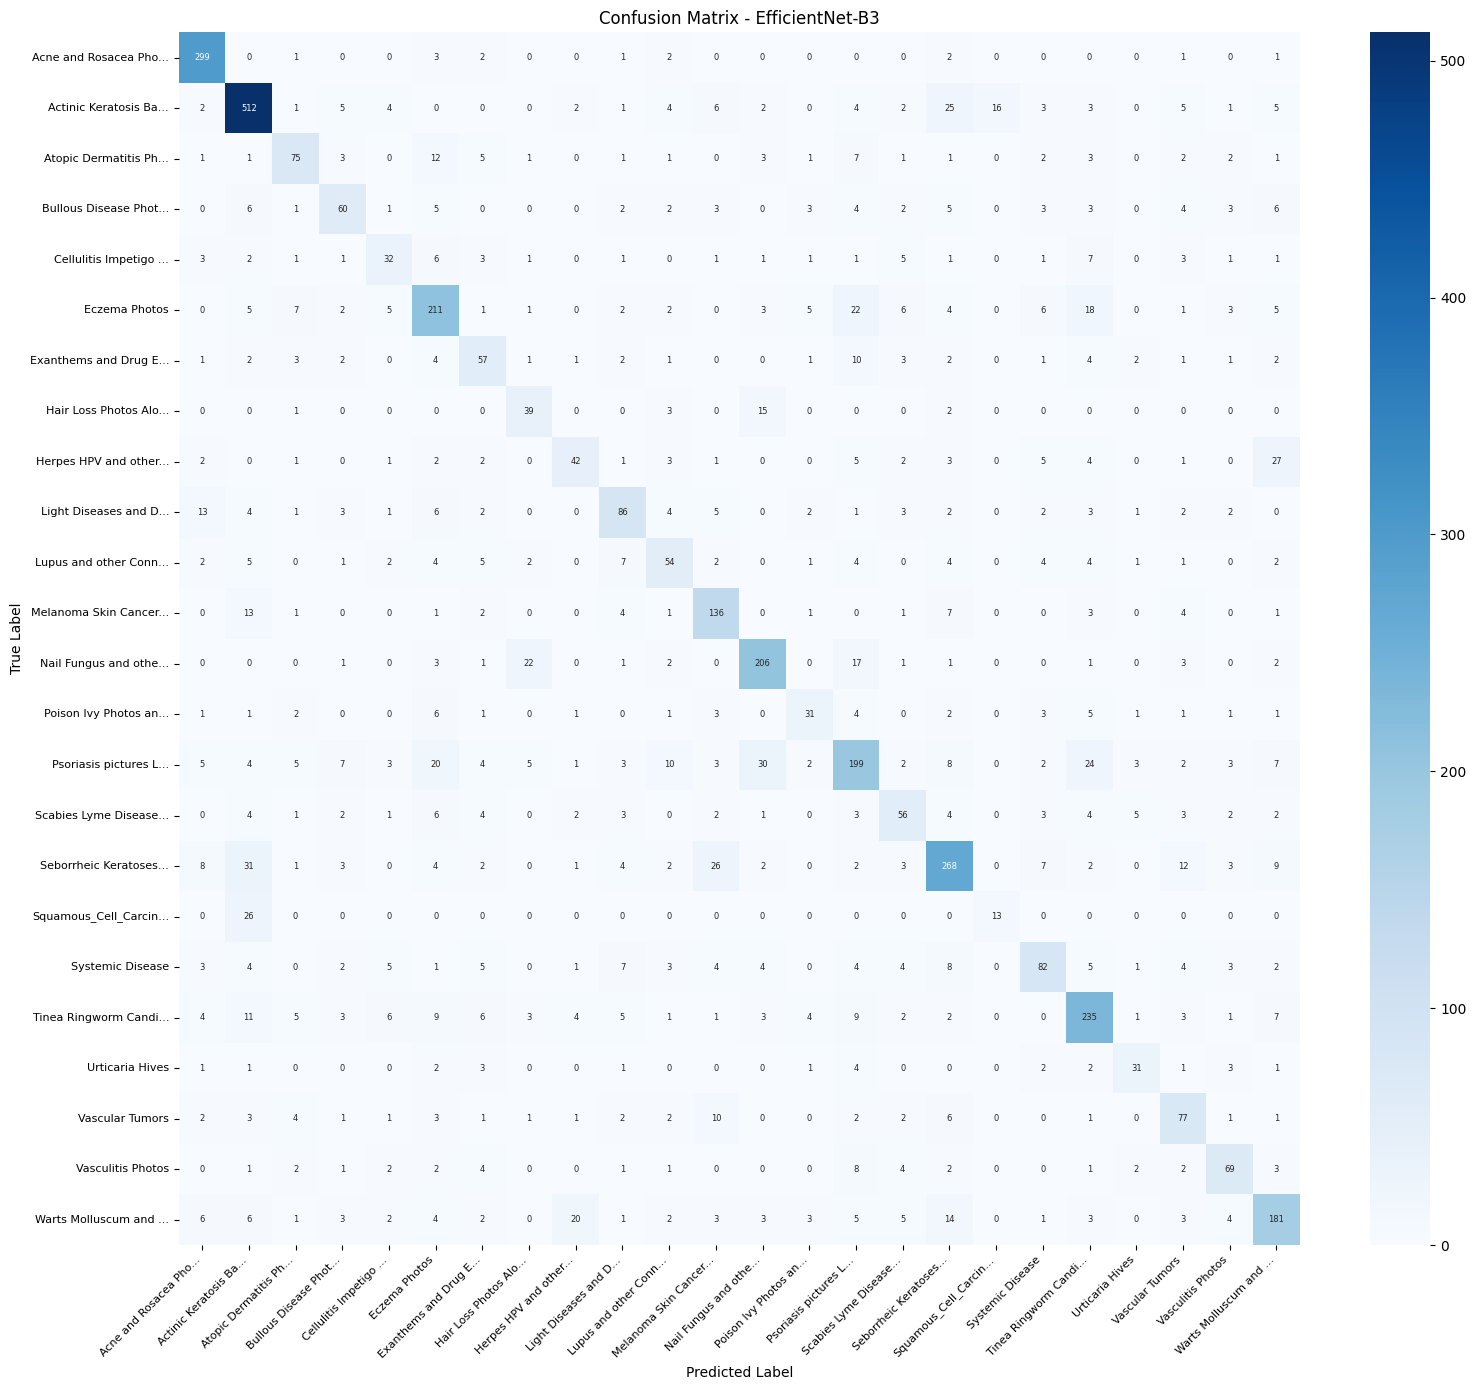


Overall Accuracy: 0.6838 (68.38%)


In [ ]:
# confusion matrix visualisation
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            annot_kws={'size': 6})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - EfficientNet-B3')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# overall accuracy
accuracy = np.sum(np.diag(cm)) / np.sum(cm)
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


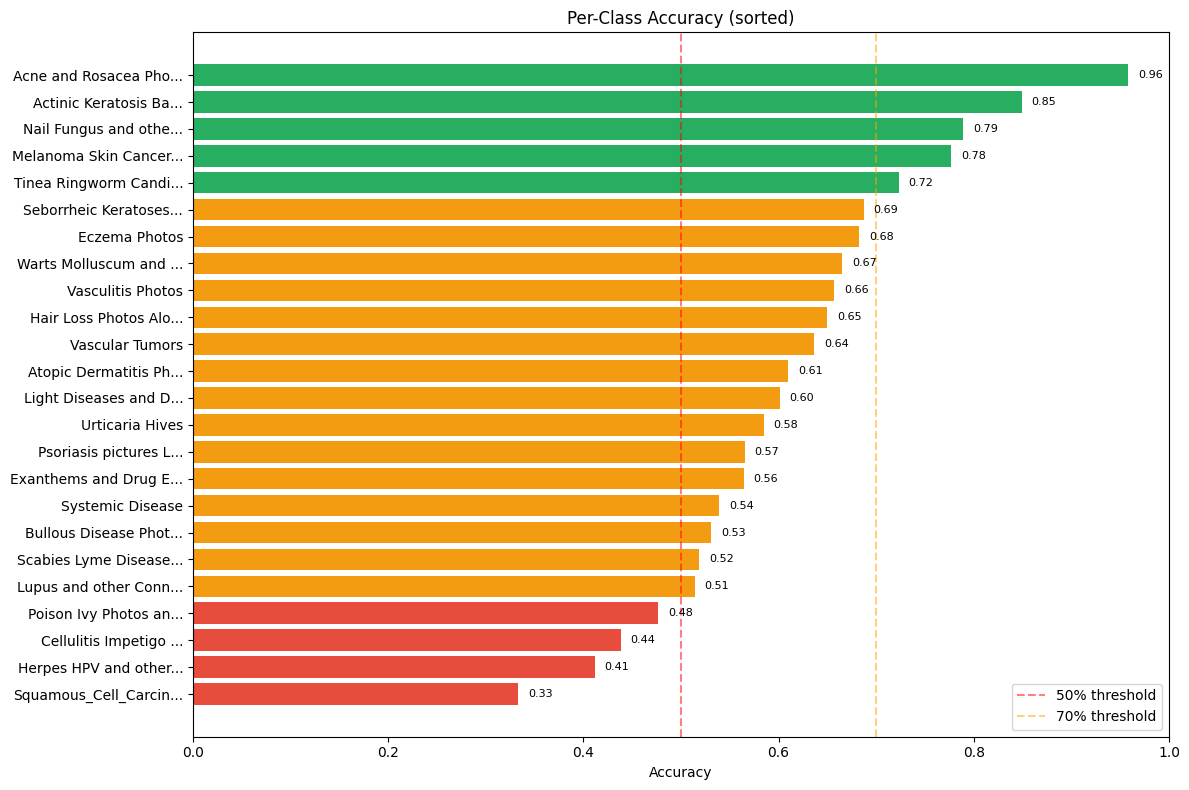


Best performing classes:
  Acne and Rosacea Photos: 0.9583
  Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions: 0.8491
  Nail Fungus and other Nail Disease: 0.7893

Worst performing classes:
  Squamous_Cell_Carcinoma: 0.3333
  Herpes HPV and other STDs Photos: 0.4118
  Cellulitis Impetigo and other Bacterial Infections: 0.4384


In [ ]:
# per-class accuracy analysis
per_class_acc = cm.diagonal() / cm.sum(axis=1)
sorted_indices = np.argsort(per_class_acc)

# plot per-class accuracy
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if acc < 0.5 else '#f39c12' if acc < 0.7 else '#27ae60' for acc in per_class_acc[sorted_indices]]
bars = ax.barh([short_names[i] for i in sorted_indices], per_class_acc[sorted_indices], color=colors)
ax.set_xlabel('Accuracy')
ax.set_title('Per-Class Accuracy (sorted)')
ax.set_xlim(0, 1)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='70% threshold')
ax.legend()

# add accuracy values on bars
for bar, acc in zip(bars, per_class_acc[sorted_indices]):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# print best and worst performing classes
print(f"\nBest performing classes:")
for i in sorted_indices[-3:][::-1]:
    print(f"  {class_names[i]}: {per_class_acc[i]:.4f}")
print(f"\nWorst performing classes:")
for i in sorted_indices[:3]:
    print(f"  {class_names[i]}: {per_class_acc[i]:.4f}")
